# Import Required Libraries

In [58]:
import pandas as pd
import csv
import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox

# Creating the Dataset

In [2]:
columns = ['Name', 'Surname', 'Gender', 'AI', 'CC', 'DSBDA', 'WT']
names = ['Niko', 'Tommy', 'Alexa', 'Sadie', 'Arthur', 'Dutch', 'Casey', 'Julia', 'Quinn', 'Ronda', 'Charlotte', 'John', 'Devin']
surnames = ['Bellic', 'Brown', 'Williams', 'Jones', 'Morgan', 'Miller', 'Convoy', 'Wanderline', 'Smith']
genders = ['Male', 'Female']
marks = (30,100)
outlier_marks = (150,200)
missing_values = ['', '?', 'na', '--']

def random_marks_assignment(allow_missing):
    if allow_missing==0:
        return random.choice([random.randint(*marks)] + missing_values)
    elif allow_missing==3:
        return random.randint(*outlier_marks)
    else:
        return random.randint(*marks)

rows = []
for i in range(30):
    row = [
        random.choice(names),
        random.choice(surnames),
        random.choice(genders),
        random_marks_assignment(i%4),
        random_marks_assignment(i%4),
        random_marks_assignment(i%4),
        random_marks_assignment(i%4)
    ]
    rows.append(row)

with open('students.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(columns)
    writer.writerows(rows)

print("CSV file students.csv has been created")

CSV file students.csv has been created


# Loading CSV

In [3]:
df = pd.read_csv('students.csv', na_values = missing_values)
print(f"CSV loaded to dataframe df having shape {df.shape}")

CSV loaded to dataframe df having shape (30, 7)


# Exploring the DataFrame

## Dimensions and Size

In [4]:
print(f"No. of Rows : {df.shape[0]}\nNo. of Columns : {df.shape[1]}\nTotal No. of Cells : {df.size}")

No. of Rows : 30
No. of Columns : 7
Total No. of Cells : 210


## Displaying Sample Rows

In [5]:
print("Top 3 rows")
display(df.head(3))

Top 3 rows


,Name,Surname,Gender,AI,CC,DSBDA,WT
0,Casey,Morgan,Female,58.0,38.0,53.0,NaN
1,Charlotte,Bellic,Female,95.0,68.0,70.0,100.0
2,Tommy,Brown,Female,60.0,97.0,69.0,90.0


In [6]:
print("Last 3 rows")
display(df.tail(3))

Last 3 rows


,Name,Surname,Gender,AI,CC,DSBDA,WT
27,Quinn,Jones,Male,165.0,159.0,177.0,153.0
28,Alexa,Convoy,Male,NaN,NaN,NaN,NaN
29,Sadie,Morgan,Male,57.0,82.0,61.0,73.0


In [7]:
print("Randomly selected 3 rows")
display(df.sample(3))

Randomly selected 3 rows


,Name,Surname,Gender,AI,CC,DSBDA,WT
25,Dutch,Williams,Male,79.0,65.0,98.0,82.0
4,Devin,Bellic,Female,NaN,NaN,NaN,NaN
23,Devin,Convoy,Male,159.0,197.0,187.0,198.0


## Metadata

In [8]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Name     30 non-null     object 
 1   Surname  30 non-null     object 
 2   Gender   30 non-null     object 
 3   AI       25 non-null     float64
 4   CC       23 non-null     float64
 5   DSBDA    24 non-null     float64
 6   WT       23 non-null     float64
dtypes: float64(4), object(3)
memory usage: 1.8+ KB


None

## Statistical Summary

In [9]:
display(df.describe())

,AI,CC,DSBDA,WT
count,25.000000,23.000000,24.000000,23.000000
mean,89.480000,100.869565,96.083333,100.782609
std,53.531237,56.041628,57.252239,49.814161
min,30.000000,36.000000,30.000000,30.000000
25%,50.000000,58.000000,57.000000,71.500000
50%,66.000000,84.000000,69.500000,82.000000
75%,155.000000,158.500000,168.500000,156.000000
max,193.000000,198.000000,191.000000,198.000000


# Data Preprocessing

## Identifying Null Values

In [10]:
display(df.isnull())

,Name,Surname,Gender,AI,CC,DSBDA,WT
0,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,True,True,True,True
5,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False
8,False,False,False,True,True,False,False
9,False,False,False,False,False,False,False


In [11]:
print(f"No. of Missing Values per Column :\n{df.isnull().sum()}\n-------------------------------------\nTotal No. of Mising Values : {df.isnull().sum().sum()}")

No. of Missing Values per Column :
Name       0
Surname    0
Gender     0
AI         5
CC         7
DSBDA      6
WT         7
dtype: int64
-------------------------------------
Total No. of Mising Values : 25


## Imputing Null Values

In [12]:
df.replace(['', '?', 'na', '--'],pd.NA, inplace=True)

In [13]:
df.head()

,Name,Surname,Gender,AI,CC,DSBDA,WT
0,Casey,Morgan,Female,58.0,38.0,53.0,NaN
1,Charlotte,Bellic,Female,95.0,68.0,70.0,100.0
2,Tommy,Brown,Female,60.0,97.0,69.0,90.0
3,Dutch,Brown,Female,193.0,198.0,191.0,164.0
4,Devin,Bellic,Female,NaN,NaN,NaN,NaN


In [14]:
numerical_columns = ['AI','CC','DSBDA','WT']

In [15]:
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].min())

In [16]:
print(f"Total No. of NULL Values after Imputation : {df.isnull().sum().sum()}")

Total No. of NULL Values after Imputation : 0


In [17]:
display(df.head())

,Name,Surname,Gender,AI,CC,DSBDA,WT
0,Casey,Morgan,Female,58.0,38.0,53.0,30.0
1,Charlotte,Bellic,Female,95.0,68.0,70.0,100.0
2,Tommy,Brown,Female,60.0,97.0,69.0,90.0
3,Dutch,Brown,Female,193.0,198.0,191.0,164.0
4,Devin,Bellic,Female,30.0,36.0,30.0,30.0


## Converting to Suitable dtypes

In [18]:
for col in numerical_columns:
    df[col] = df[col].astype(int)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     30 non-null     object
 1   Surname  30 non-null     object
 2   Gender   30 non-null     object
 3   AI       30 non-null     int64 
 4   CC       30 non-null     int64 
 5   DSBDA    30 non-null     int64 
 6   WT       30 non-null     int64 
dtypes: int64(4), object(3)
memory usage: 1.8+ KB


# EDA

## Identifying Outliers

In [44]:
Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)
IQR = Q3 - Q1

In [48]:
# lower_bound = Q1 - 1.5*IQR
# upper_bound = Q3 + 1.5*IQR
lower_bound = 30
upper_bound = 100 #For our sake of understanding with real world we've modified the stds

In [49]:
outliers = (df[numerical_columns] < lower_bound) | (df[numerical_columns] > upper_bound)

In [50]:
print(f"Outliers detected in each column :\n{outliers.sum()}")

Outliers detected in each column :
AI       7
CC       7
DSBDA    7
WT       7
dtype: int64


## Visualizing Outliers

### BoxPlot

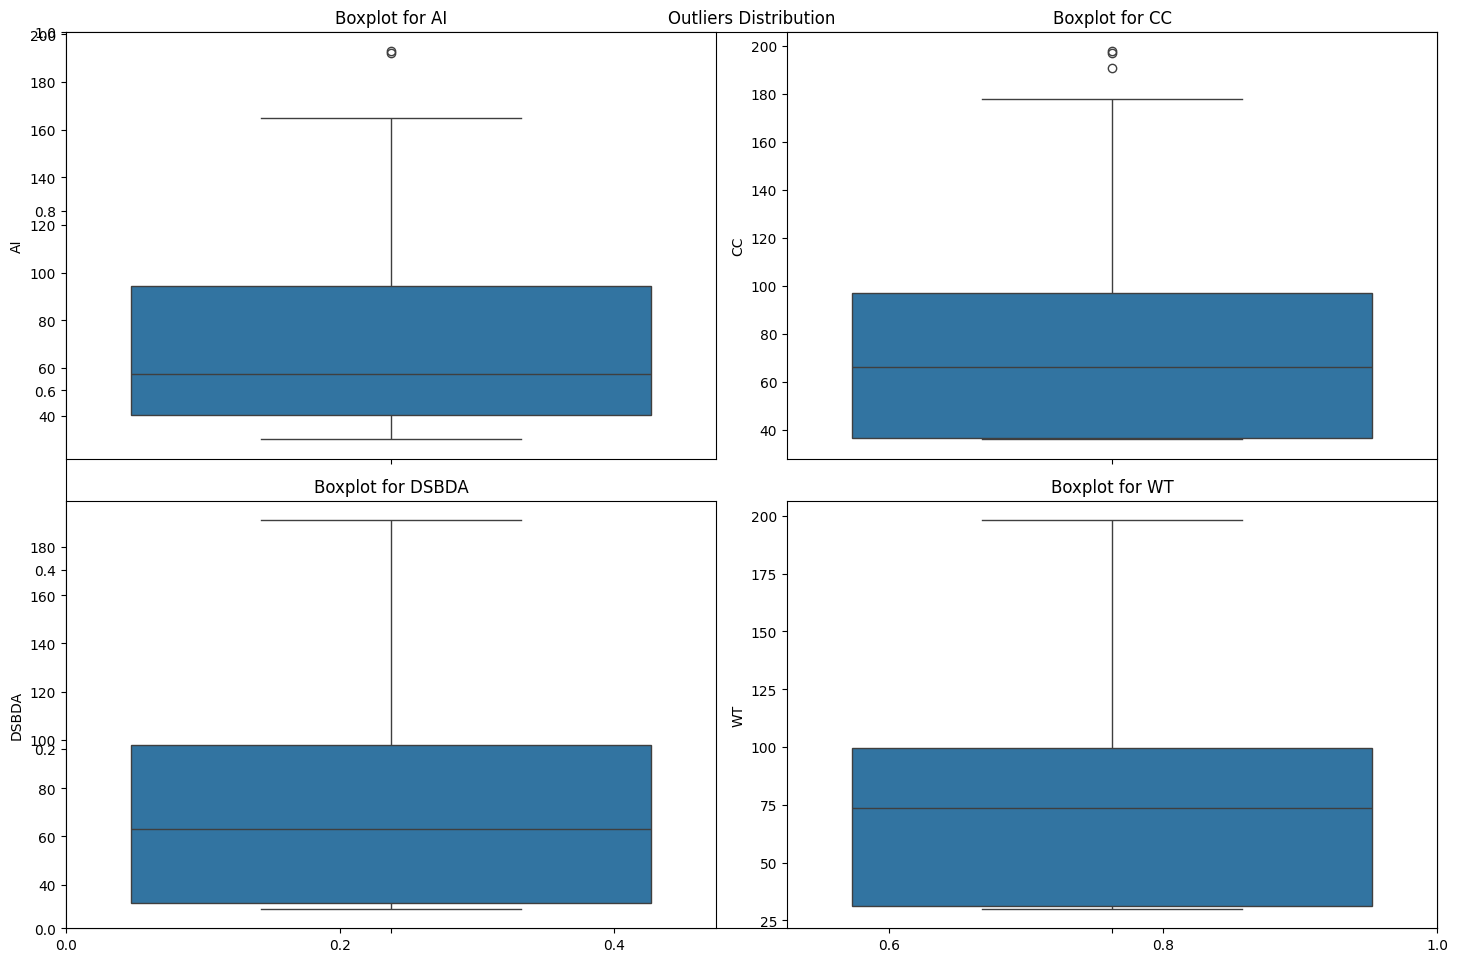

In [51]:
plt.figure(figsize=(15,10))
plt.title("Outliers Distribution")
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2,2,i)
    sns.boxplot(data=df, y=column)
    plt.title(f"Boxplot for {column}")
plt.tight_layout()
plt.show()

### ViolinPlot

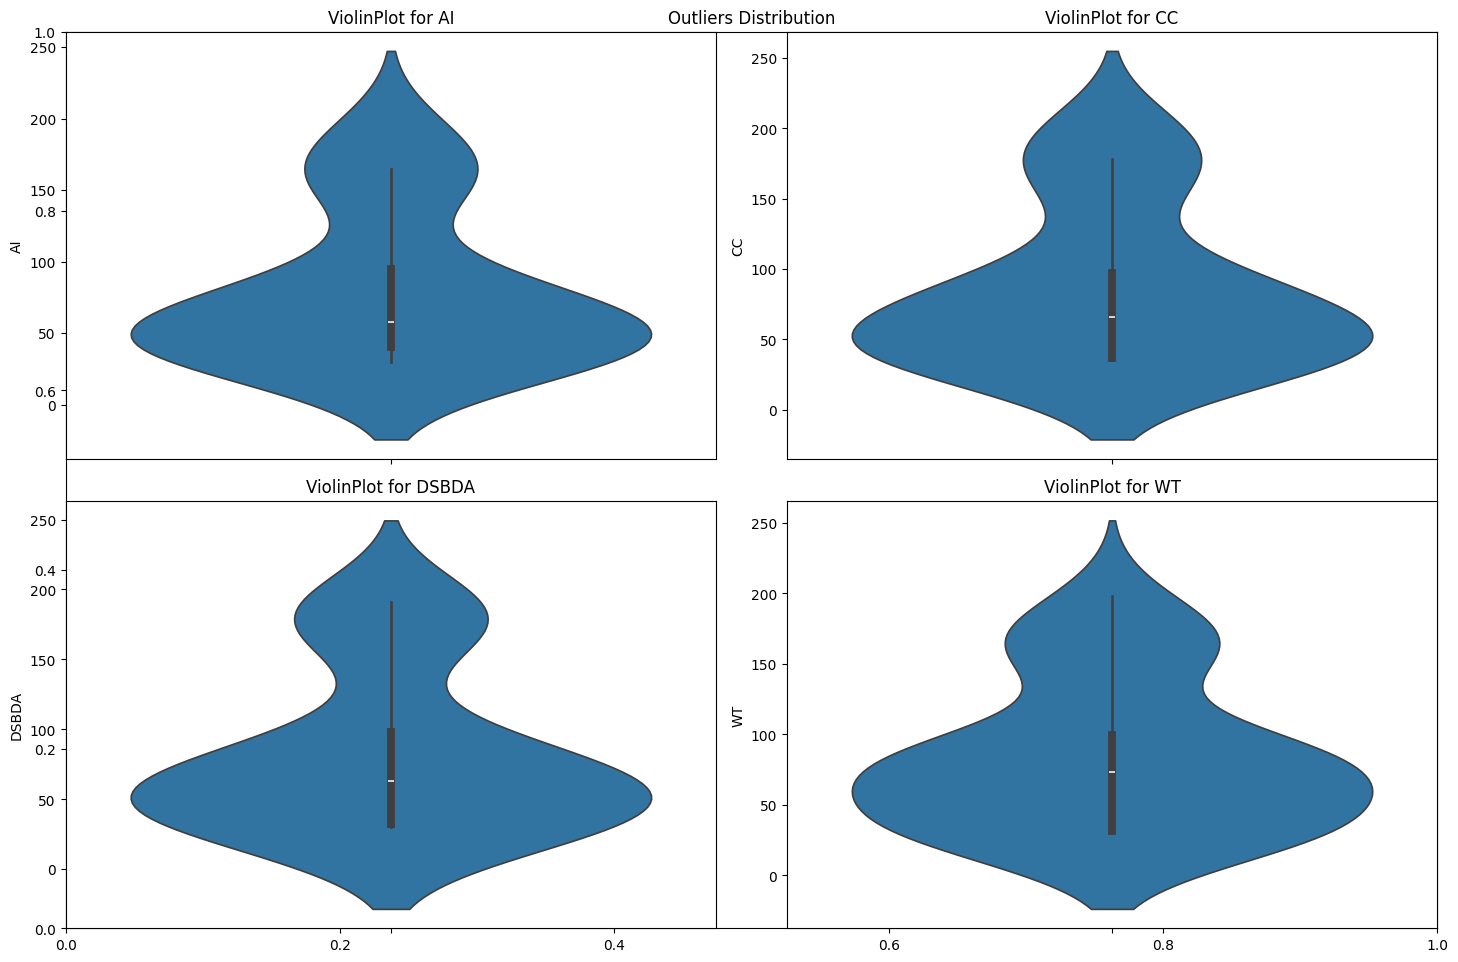

In [52]:
plt.figure(figsize=(15,10))
plt.title("Outliers Distribution")
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2,2,i)
    sns.violinplot(data=df, y=column)
    plt.title(f"ViolinPlot for {column}")
plt.tight_layout()
plt.show()

### SwarmPlot

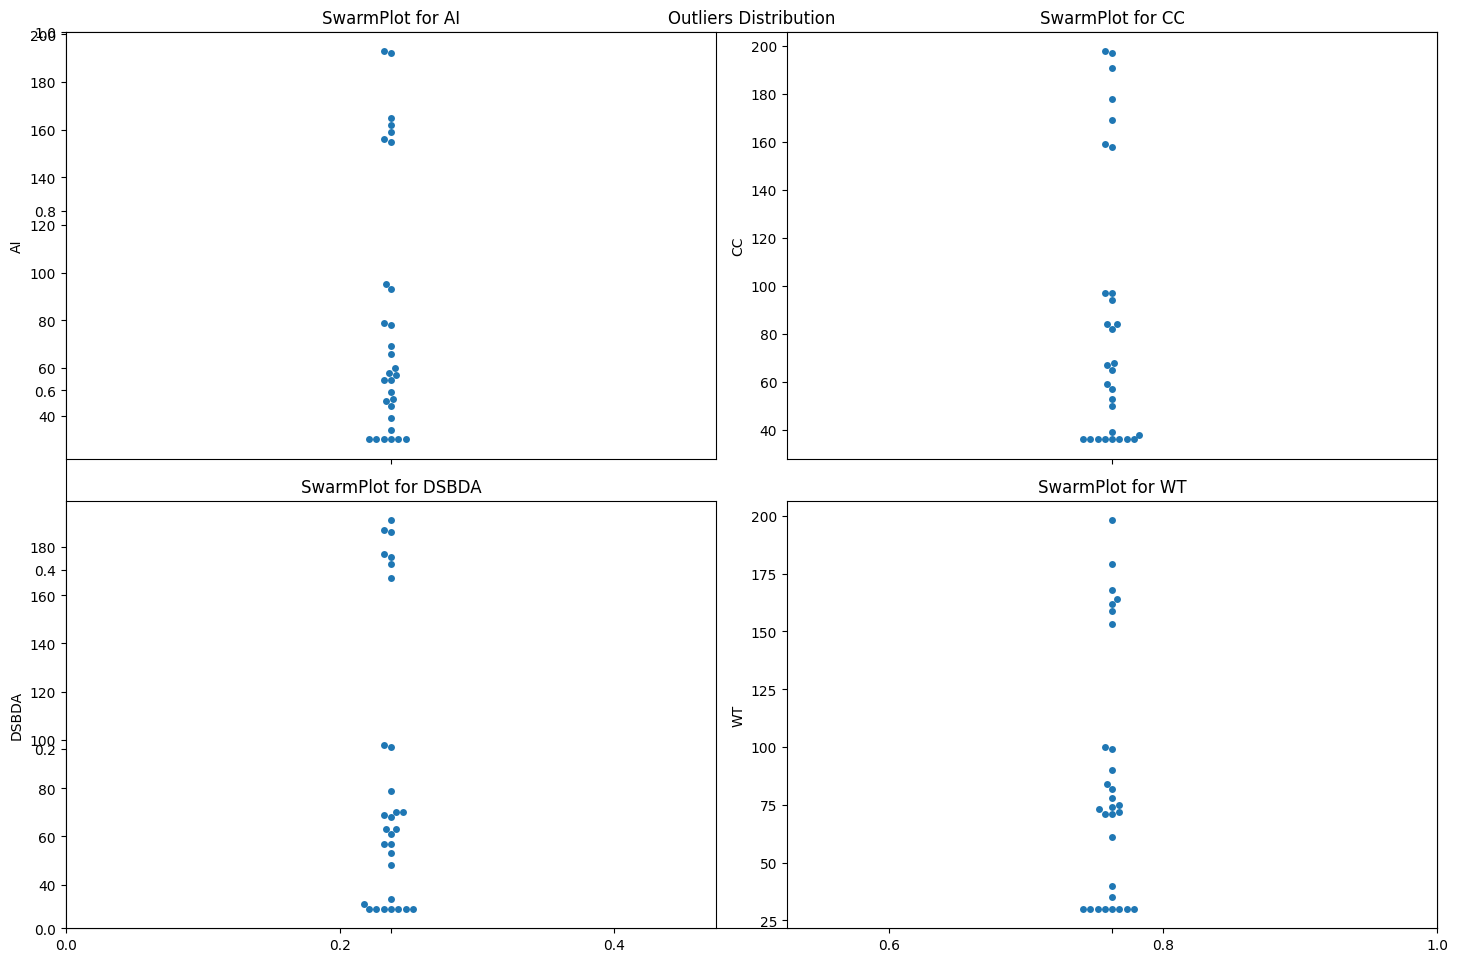

In [53]:
plt.figure(figsize=(15,10))
plt.title("Outliers Distribution")
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2,2,i)
    sns.swarmplot(data=df, y=column)
    plt.title(f"SwarmPlot for {column}")
plt.tight_layout()
plt.show()

# Removing Outliers

In [54]:
df_cleaned = df[~outliers.any(axis=1)]

In [55]:
print(f"Cleaned DataFrame Shape : {df_cleaned.shape}")

Cleaned DataFrame Shape : (23, 7)


In [56]:
display(df_cleaned.describe())

,AI,CC,DSBDA,WT
count,23.000000,23.000000,23.000000,23.000000
mean,52.391304,57.478261,53.434783,58.478261
std,20.321818,22.576878,21.864929,25.720295
min,30.000000,36.000000,30.000000,30.000000
25%,32.000000,36.000000,30.000000,30.000000
50%,50.000000,53.000000,57.000000,71.000000
75%,63.000000,75.000000,68.500000,76.500000
max,95.000000,97.000000,98.000000,100.000000


## Visualizing Cleaned Dataframe

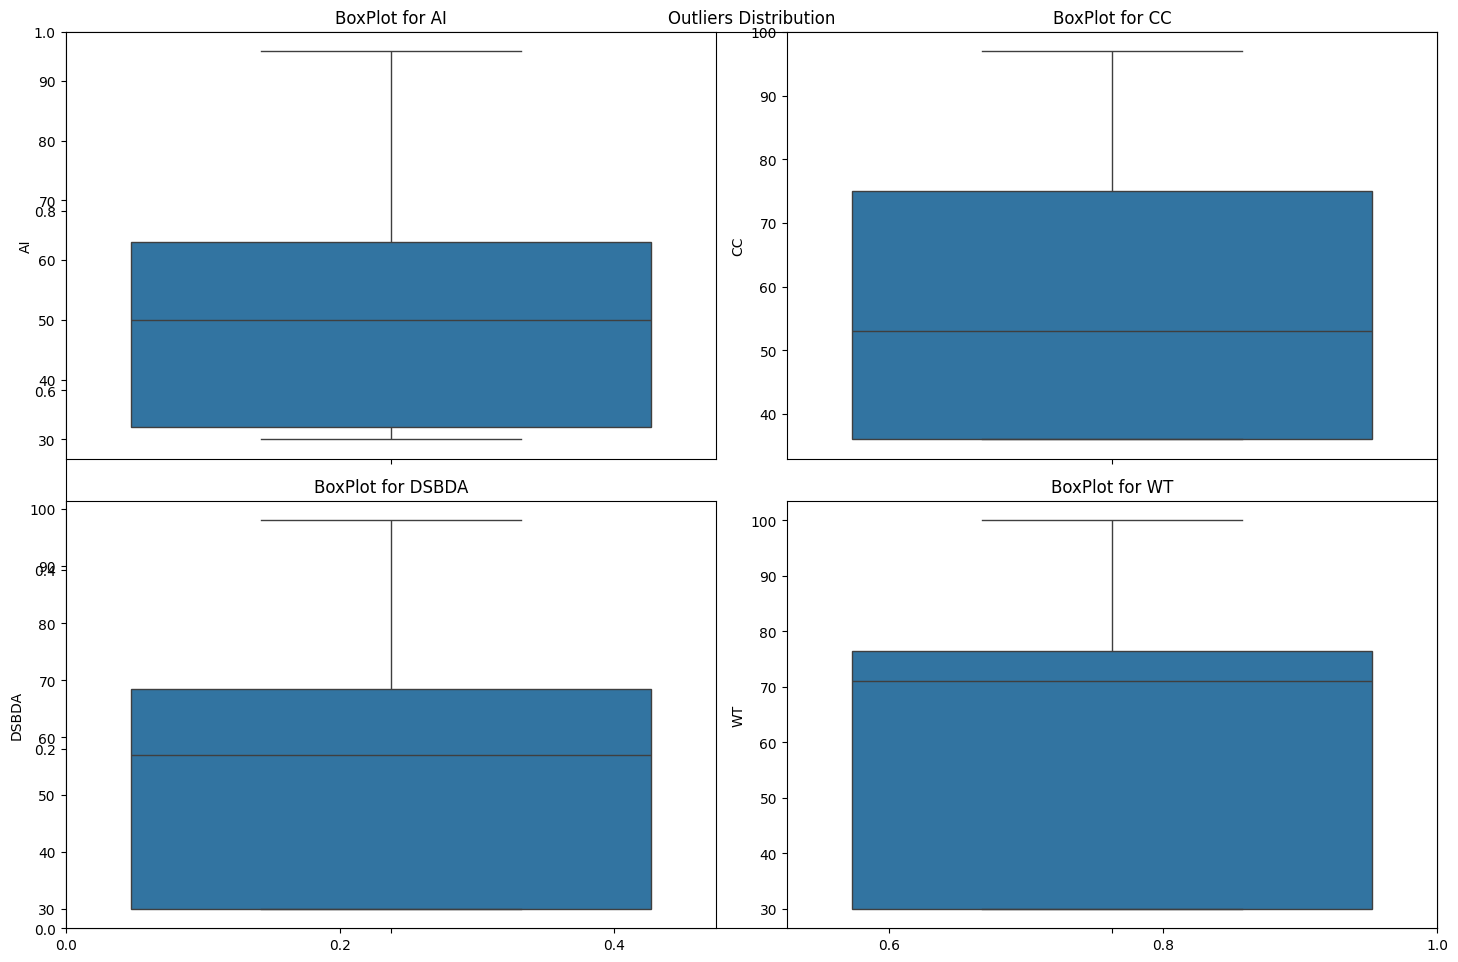

In [57]:
plt.figure(figsize=(15,10))
plt.title("Outliers Distribution")
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(2,2,i)
    sns.boxplot(data=df_cleaned, y=column)
    plt.title(f"BoxPlot for {column}")
plt.tight_layout()
plt.show()

# Data Transformation

In [61]:
df_cleaned['DSBDA_BoxCox'], lambda_val = boxcox(df_cleaned['DSBDA'])
print(f"Lambda used: {lambda_val}")

Lambda used: 0.027335590853110627


C:\Users\Karunya\AppData\Local\Temp\ipykernel_8236\460326700.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['DSBDA_BoxCox'], lambda_val = boxcox(df_cleaned['DSBDA'])


In [62]:
df_cleaned.head()

,Name,Surname,Gender,AI,CC,DSBDA,WT,DSBDA_Log,DSBDA_BoxCox
0,Casey,Morgan,Female,58,38,53,30,4.193751,4.193751
1,Charlotte,Bellic,Female,95,68,70,100,4.505029,4.505029
2,Tommy,Brown,Female,60,97,69,90,4.488872,4.488872
4,Devin,Bellic,Female,30,36,30,30,3.564325,3.564325
5,Alexa,Wanderline,Female,34,59,30,71,3.564325,3.564325


## Visualizing the Benefit Of Transformation

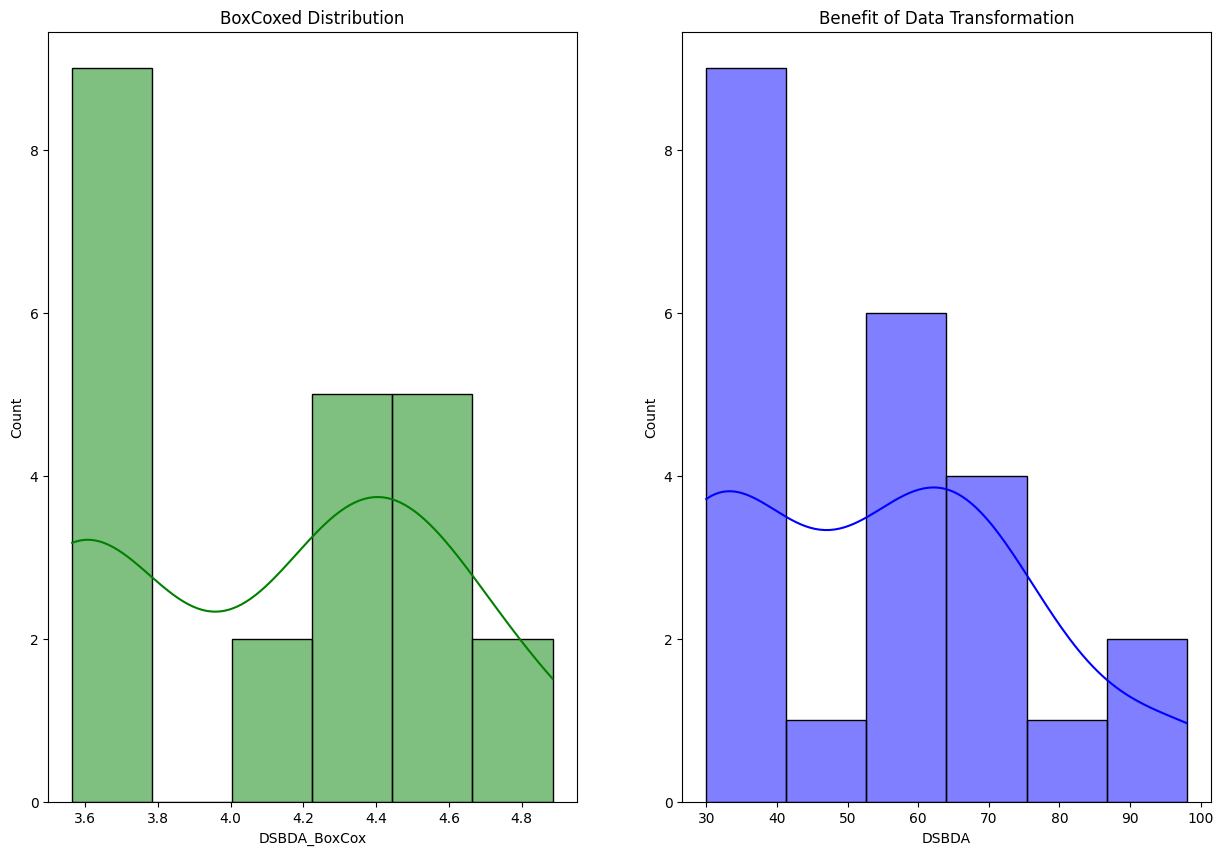

In [63]:
plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
sns.histplot(df_cleaned['DSBDA_BoxCox'], kde=True, color='green')
plt.title('BoxCoxed Distribution')

plt.subplot(1,2,2)
sns.histplot(df_cleaned['DSBDA'], kde=True, color='blue')
plt.title('Original Distribution')

plt.title('Benefit of Data Transformation')
plt.show()